In [21]:
pip install pandas numpy matplotlib seaborn scikit-learn shap eli5 openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.6 MB/s eta 0:00:00


In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
from google.colab import files
uploaded=files.upload()

Saving Telco_customer_churn_day.xlsx to Telco_customer_churn_day.xlsx


In [14]:
df=pd.read_excel("Telco_customer_churn_day.xlsx")

In [15]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [19]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [20]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [29]:
df=df.drop(['CustomerID','Country','State','City','Zip Code','Lat Long','Latitude','Longitude'],axis=1)

In [31]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.fillna(0,inplace=True)

In [32]:
y = df['Churn Value']

In [33]:
df = df.drop(['Churn Label','Churn Reason'], axis=1)

In [34]:
label = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label.fit_transform(df[col])

In [35]:
X = df.drop(['Churn Value'], axis=1)

In [36]:
X.head()

,Count,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Score,CLTV
0,1,1,0,0,0,2,1,0,0,2,...,0,0,0,0,1,3,53.85,108.15,86,3239
1,1,0,0,0,1,2,1,0,1,0,...,0,0,0,0,1,2,70.70,151.65,67,2701
2,1,0,0,0,1,8,1,2,1,0,...,0,2,2,0,1,2,99.65,820.50,86,5372
3,1,0,0,1,1,28,1,2,1,0,...,2,2,2,0,1,2,104.80,3046.05,84,5003
4,1,1,0,0,1,49,1,2,1,0,...,0,2,2,0,1,0,103.70,5036.30,89,5340


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [40]:
y_pred = model.predict(X_test)

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9304471256210078


In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1009
           1       0.89      0.86      0.88       400

    accuracy                           0.93      1409
   macro avg       0.92      0.91      0.91      1409
weighted avg       0.93      0.93      0.93      1409



In [43]:
print(confusion_matrix(y_test, y_pred))

[[966  43]
 [ 55 345]]


In [44]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

              Feature  Importance
20        Churn Score    0.492818
5       Tenure Months    0.076628
19      Total Charges    0.068126
18    Monthly Charges    0.062033
15           Contract    0.055489
21               CLTV    0.049586
9     Online Security    0.027966
12       Tech Support    0.025025
4          Dependents    0.019143
17     Payment Method    0.019058
8    Internet Service    0.016650
10      Online Backup    0.015673
11  Device Protection    0.011042
16  Paperless Billing    0.010601
7      Multiple Lines    0.009519
1              Gender    0.008728
3             Partner    0.008165
14   Streaming Movies    0.007301
13       Streaming TV    0.007236
2      Senior Citizen    0.007075
6       Phone Service    0.002137
0               Count    0.000000


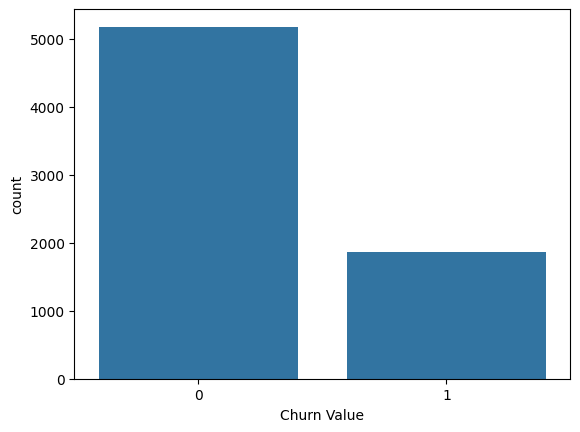

In [45]:
sns.countplot(x='Churn Value', data=df)
plt.show()

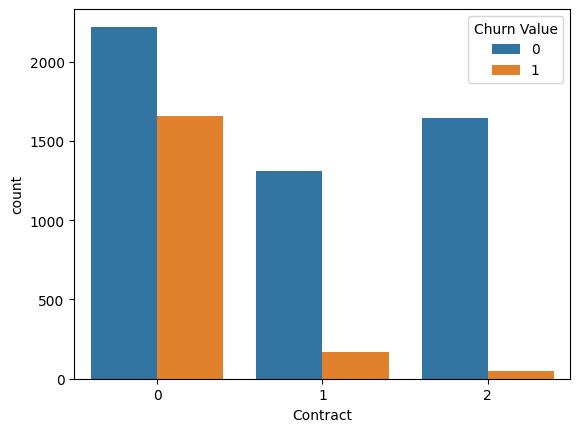

In [46]:
sns.countplot(x='Contract', hue='Churn Value', data=df)
plt.show()

In [47]:
def segment_customer(row):

    if row['Tenure Months'] > 24:
        return "Loyal"

    elif row['Tenure Months'] < 12 and row['Monthly Charges'] > 80:
        return "At Risk"

    else:
        return "Dormant"

df['Customer Segment'] = df.apply(segment_customer, axis=1)

In [48]:
df['Customer Segment'].value_counts()

,count
Customer Segment,
Loyal,3833
Dormant,2771
At Risk,439


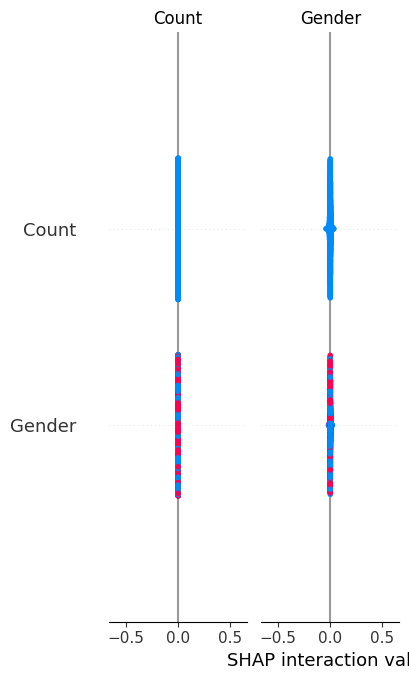

In [49]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)